In [110]:
import uproot
import os
import glob
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap
import mplhep as hep
import seaborn as sns
import ROOT
import pandas as pd
from scipy import stats
import numpy as np
from scipy.optimize import minimize, curve_fit
from scipy.stats import moment
import json
from itertools import combinations  

In [103]:
# Importing translation dictionary
translationFilePath = "/work/niharrin/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Bootstrap/translation.json"
with open(translationFilePath) as translationFile:
    translation = json.load(translationFile)

In [3]:
def pois_untrimmed(toyDir_, poi_list_):
    pois = {}

    for current_poi in poi_list_:

        pois[current_poi] = []

    for i in range(len(glob.glob(os.path.join(toyDir_, "toy_*")))):

        if i%100==0:
            print(f"Processing fit_{i}")

        try:
            current_root_files = uproot.open(f"{toyDir_}/toy_{i}/higgsCombinefirstStep.MultiDimFit.mH125.38.root")
        except:
            print(f"Skipping fit_{i}: Required scan files not found")
            for current_poi in poi_list_:
                pois[current_poi].append(-999.0)
            continue

        for j, current_poi in enumerate(poi_list_):

            try: 
                current_tree = current_root_files["limit"]
            except:
                print(f"Skipping fit_{i}: Tree 'limit' not found in ROOT file")
                pois[current_poi].append(-999.0)
                continue

            current_limit_values = current_tree[current_poi].array()

            try:
                if current_limit_values[0]<-4:
                    print("Value out of boundary", current_limit_values[0], i)
            except:
                if j == 0:
                    print("Empty ROOT file for bootstrap: ", i)
                pois[current_poi].append(-999.0)
                continue

            pois[current_poi].append(float(current_limit_values[0]))
    return pois

In [4]:
def pois_trimmed(toyDir_, poi_list_, trimming_value_left_, trimming_value_right_):
    pois = {}

    for current_poi in poi_list_:

        pois[current_poi] = []

    for i in range(len(glob.glob(os.path.join(toyDir_, "toy_*")))):

        if i%100==0:
            print(f"Processing fit_{i}")

        try:
            current_root_files = uproot.open(f"{toyDir_}/toy_{i}/higgsCombinefirstStep.MultiDimFit.mH125.38.root")
        except:
            print(f"Skipping fit_{i}: Required scan files not found")
            for current_poi in poi_list_:
                pois[current_poi].append(-999.0)
            continue

        kill_event = False

        # First loop to check if there are outliers (outliers are events smaller than -4 and bigger than 4)
        for j, current_poi in enumerate(poi_list_):
            try: 
                current_tree = current_root_files["limit"]
            except:
                print(f"Skipping fit_{i}: Tree 'limit' not found in ROOT file")
                pois[current_poi].append(-999.0)
                continue

            current_limit_values = current_tree[current_poi].array()

            try:
                if (current_limit_values[0] > trimming_value_right_) or (current_limit_values[0] < trimming_value_left_):
                    kill_event = True 
                    break
            except:
                if j == 0:
                    print("Empty ROOT file for bootstrap: ", i)
                pois[current_poi].append(-999.0)
                continue

        if kill_event:
            print(f"Skipping fit_{i} with {current_limit_values[0]}: Outlier found")
            for current_poi in poi_list_:
                pois[current_poi].append(-999.0)
            continue

        for j, current_poi in enumerate(poi_list_):

            try: 
                current_tree = current_root_files["limit"]
            except:
                print(f"Skipping fit_{i}: Tree 'limit' not found in ROOT file")
                continue

            current_limit_values = current_tree[current_poi].array()

            try:
                if current_limit_values[0]<-4:
                    print("Value out of boundary", current_limit_values[0], i)
            except:
                if j == 0:
                    print("Empty ROOT file for bootstrap: ", i)
                continue

            pois[current_poi].append(float(current_limit_values[0]))
    return pois

In [5]:
def create_json_untrimmed(variable_, toyDir_, poi_list_, extra_name=""):
    # Loop through all fit directories (fit_0, fit_1, etc.)
    if not os.path.exists(f'pois_untrimmed_{variable_}{extra_name}.json'):
        pois = pois_untrimmed(toyDir_, poi_list_)
        # Save the POIs to a JSON file
        with open(f'pois_untrimmed_{variable_}{extra_name}.json', 'w') as f:
            json.dump(pois, f)
    else:
        # Load the POIs from the JSON file
        with open(f'pois_untrimmed_{variable_}{extra_name}.json', 'r') as f:
            pois = json.load(f)

    return pois


In [13]:

def gaus(x, amp, mu, sigma):
    return amp * np.exp(-(x - mu)**2 / (2 * sigma**2))

def create_json_trimmed(variable_, toyDir_, pois_untrimmed_, poi_list_, subfolder_, extra_name=""):

    # Now we have to fit a gaussian core to all the categories to get the values where we cut. z is the number of standard deviations we want to cut away
    trimming_value_left = 0
    trimming_value_right = 0
    largest_sigma = 0
    mu_to_largest_sigma = 0
    z = 4 # 4
    for i, current_poi in enumerate(poi_list_):
        r = np.array(pois_untrimmed_[current_poi])
        # Disregard -999 values
        r = r[r > -998.0]
        r = r[r < 2.0]
        mean = np.mean(r)
        s = np.std(r)

        counts, bin_edges = np.histogram(r, bins=50, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        popt, _ = curve_fit(gaus, bin_centers, counts, p0=[1, mean, s])
        amp_fit, mu_fit, sigma_fit = popt

        if i == 0:
            largest_sigma = sigma_fit
            mu_to_largest_sigma = mu_fit
        else:
            if (sigma_fit > largest_sigma):
                largest_sigma = sigma_fit
                mu_to_largest_sigma = mu_fit

        if (not os.path.exists(f"./Plots/{variable_}/{subfolder_}{extra_name}")) & (f"./Plots/{variable_}/{subfolder_}{extra_name}"!=""):
            os.makedirs(f"./Plots/{variable_}/{subfolder_}{extra_name}")

        plt.figure()
        plt.hist(r, bins=30, density=True, alpha=0.6, label='Histogram')
        plt.plot(bin_centers, gaus(bin_centers, *popt), color='red', label='Fitted Gaussian')
        plt.legend()
        plt.xlabel('Value')
        plt.ylabel('Density')
        plt.title('Gaussian Fit to Data Histogram')
        plt.savefig(f"./Plots/{variable_}/{subfolder_}{extra_name}/gaussian_fit_{current_poi}.png")
        plt.close()

    trimming_value_left = mu_to_largest_sigma - z*largest_sigma
    trimming_value_right = mu_to_largest_sigma + z*largest_sigma

    print("Trimming values: ", trimming_value_left, trimming_value_right)

    if trimming_value_left > trimming_value_right:
        trimming_value_left, trimming_value_right = trimming_value_right, trimming_value_left

    if not os.path.exists(f'pois_trimmed_{variable_}{extra_name}.json'):
        pois = pois_trimmed(toyDir_, poi_list_, trimming_value_left, trimming_value_right)
        # Save the POIs to a JSON file
        with open(f'pois_trimmed_{variable_}{extra_name}.json', 'w') as f:
            json.dump(pois, f)
    else:
        # Load the POIs from the JSON file
        with open(f'pois_trimmed_{variable_}{extra_name}.json', 'r') as f:
            pois = json.load(f)
    
    return pois



In [14]:
def plot_all_individual_correlation(pois_, poi_list_, variable_):

    unique_pairings = list(combinations(poi_list_, 2))

    for current_tuple in unique_pairings:
        r_1, r_2 = current_tuple
        
        plot_individual_correlation([x for x in pois_[r_1] if x > -998.0], [x for x in pois_[r_2] if x > -998.0], r_1, r_2, np.corrcoef([x for x in pois_[r_1] if x > -998.0], [x for x in pois_[r_2] if x > -998.0])[0,1], folder=f"Plots/{variable_}")

def plot_individual_correlation(x_vals, y_vals, x_name, y_name, rho_, folder=""):
    # rho is here a number
    if (not os.path.exists(folder)) & (folder!=""):
        os.makedirs(folder)
    plt.style.use(hep.style.CMS)
    _, ax = plt.subplots(figsize=(12, 7))
    hep.cms.label('Preliminary', data=False, lumi=9.5, com=13.6)
    ax.scatter(x_vals, y_vals, color="black", marker="x", label="Manual Toys")
    ax.set_xlabel(translation[x_name])
    ax.set_ylabel(translation[y_name])
    bbox_props = dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor="black")
    ax.text(0.05, 0.175, f"$\\rho = {rho_:.3f}$", transform=ax.transAxes, bbox=bbox_props, fontsize=18)
    leg = ax.legend(fancybox=True, loc="lower right", frameon=True)
    leg.get_frame().set_alpha(0.9)  # Now this actually applies
    plt.savefig(os.path.join(folder, f"{x_name}_vs_{y_name}.pdf"), bbox_inches='tight')
    plt.savefig(os.path.join(folder, f"{x_name}_vs_{y_name}.png"), bbox_inches='tight')
    plt.close()


In [15]:
plot_dir = "Plots"
os.makedirs(plot_dir, exist_ok=True)

In [71]:
# Load PTH toys
variable = "PTH"
sample_dir = '/pnfs/psi.ch/cms/trivcat/store/user/niharrin/ntuples/midRun3/samples/2025_07_17_powheg/finalfits'
main_dir = os.path.join(sample_dir, variable, "Combine", f"runFits_{variable}")
toyDir = os.path.join(main_dir, "toyFit")

poi_list = ["r_PTH_0p0_15p0", "r_PTH_15p0_30p0", "r_PTH_30p0_45p0", "r_PTH_45p0_80p0", "r_PTH_80p0_120p0", "r_PTH_120p0_200p0", "r_PTH_200p0_350p0", "r_PTH_350p0_10000p0"]

pois_untrimmed_PTH = create_json_untrimmed(variable, toyDir, poi_list)
pois_PTH = create_json_trimmed(variable, toyDir, pois_untrimmed_PTH, poi_list, subfolder_=f"SL_{variable}")

Trimming values:  -4.568976929399344 6.831910574544848


In [72]:
# df_PTH = pd.DataFrame(pois_untrimmed_PTH)
# print(df_PTH[(df_PTH['r_PTH_350p0_10000p0'] > -998.0) & (df_PTH['r_PTH_350p0_10000p0'] < -15.8)]['r_PTH_350p0_10000p0'].index.tolist())

In [73]:
# Load NJ toys
variable = "NJ"
sample_dir = '/pnfs/psi.ch/cms/trivcat/store/user/niharrin/ntuples/midRun3/samples/2025_07_17_powheg/finalfits'
main_dir = os.path.join(sample_dir, variable, "Combine", f"runFits_{variable}")
toyDir = os.path.join(main_dir, "toyFit")

poi_list_NJ = ["r_NJ_0p0_1p0", "r_NJ_1p0_2p0", "r_NJ_2p0_3p0", "r_NJ_3p0_100p0"]

pois_untrimmed_NJ = create_json_untrimmed(variable, toyDir, poi_list_NJ)
pois_NJ = create_json_trimmed(variable, toyDir, pois_untrimmed_NJ, poi_list_NJ, subfolder_=f"SL_{variable}")

Trimming values:  -9.325856650176558 10.791714800140031


In [74]:
# Load PTJ0 toys
variable = "PTJ0"
sample_dir = '/pnfs/psi.ch/cms/trivcat/store/user/niharrin/ntuples/midRun3/samples/2025_07_17_powheg/finalfits'
main_dir = os.path.join(sample_dir, variable, "Combine", f"runFits_{variable}")
toyDir = os.path.join(main_dir, "toyFit")

poi_list_PTJ0 = ["r_PTJ0_0p0_30p0", "r_PTJ0_30p0_75p0", "r_PTJ0_75p0_120p0", "r_PTJ0_120p0_200p0", "r_PTJ0_200p0_10000p0"]

pois_untrimmed_PTJ0 = create_json_untrimmed(variable, toyDir, poi_list_PTJ0)
pois_PTJ0 = create_json_trimmed(variable, toyDir, pois_untrimmed_PTJ0, poi_list_PTJ0, subfolder_=f"SL_{variable}")

Trimming values:  -7.320780541765041 8.996269721844895


In [75]:
df_PTH = pd.DataFrame(pois_PTH)
df_NJ = pd.DataFrame(pois_NJ)
df_PTJ0 = pd.DataFrame(pois_PTJ0)
print(df_PTH)
print(df_NJ)
print(df_PTJ0)

       r_PTH_0p0_15p0  r_PTH_15p0_30p0  r_PTH_30p0_45p0  r_PTH_45p0_80p0  \
0            0.527926         1.054036         0.029665         0.720660   
1         -999.000000      -999.000000      -999.000000      -999.000000   
2            0.246981         1.456664         0.386870        -0.831521   
3           -0.245229         1.678102         1.004602         1.688729   
4         -999.000000      -999.000000      -999.000000      -999.000000   
...               ...              ...              ...              ...   
19995       -0.751992         2.238265        -1.629680         2.584459   
19996        0.258053         1.344346         1.523896        -0.995070   
19997     -999.000000      -999.000000      -999.000000      -999.000000   
19998     -999.000000      -999.000000      -999.000000      -999.000000   
19999        0.258879        -0.247228        -0.238288         3.436697   

       r_PTH_80p0_120p0  r_PTH_120p0_200p0  r_PTH_200p0_350p0  \
0              0.85710

In [76]:

# --- Step 1: Identify rows WITHOUT -999 in either DataFrame ---
# Mask for df_PTH (True = valid, False = -999)
mask_pth = (df_PTH != -999).all(axis=1)

# Mask for df_NJ (True = valid, False = -999)
mask_nj = (df_NJ != -999).all(axis=1)

# # Mask for df_PTJ0 (True = valid, False = -999)
mask_ptj0 = (df_PTJ0 != -999).all(axis=1)

# Combined mask (keep only rows valid in BOTH DataFrames)
valid_rows = mask_pth & mask_nj & mask_ptj0

# --- Step 2: Filter DataFrames ---
df_PTH_clean = df_PTH[valid_rows]
df_NJ_clean = df_NJ[valid_rows]
df_PTJ0_clean = df_PTJ0[valid_rows]

# --- Step 3: Compute Correlation Matrix ---
# Combine columns (now aligned and cleaned)
df_combined = pd.concat([df_PTH_clean, df_NJ_clean, df_PTJ0_clean], axis=1)

# Calculate full correlation matrix
corr_matrix = df_combined.corr()

# # Extract cross-correlations (PTH vs. NJ bins)
# pth_cols = df_PTH.columns
# nj_cols = df_NJ.columns
# ptj0_cols = df_PTJ0.columns
# print(ptj0_cols)
# cross_corr = corr_matrix.loc[pth_cols, nj_cols, ptj0_cols]

# print("Correlation Matrix (Excluding Rows with -999):")
# print(cross_corr)

In [111]:
# 1️⃣ Define your stops and RGB values
stops = [0.0, 0.5, 1.0]
red   = [0.992, 1.0, 0.110]
green = [0.749, 1.0, 0.196]
blue  = [0.106, 1.0, 0.867]

# 2️⃣ Build the color dictionary
cdict = {
    'red':   [(stops[i], red[i], red[i]) for i in range(len(stops))],
    'green': [(stops[i], green[i], green[i]) for i in range(len(stops))],
    'blue':  [(stops[i], blue[i], blue[i]) for i in range(len(stops))]
}

# 3️⃣ Create the colormap
custom_cmap = LinearSegmentedColormap('gradient_8289', cdict)

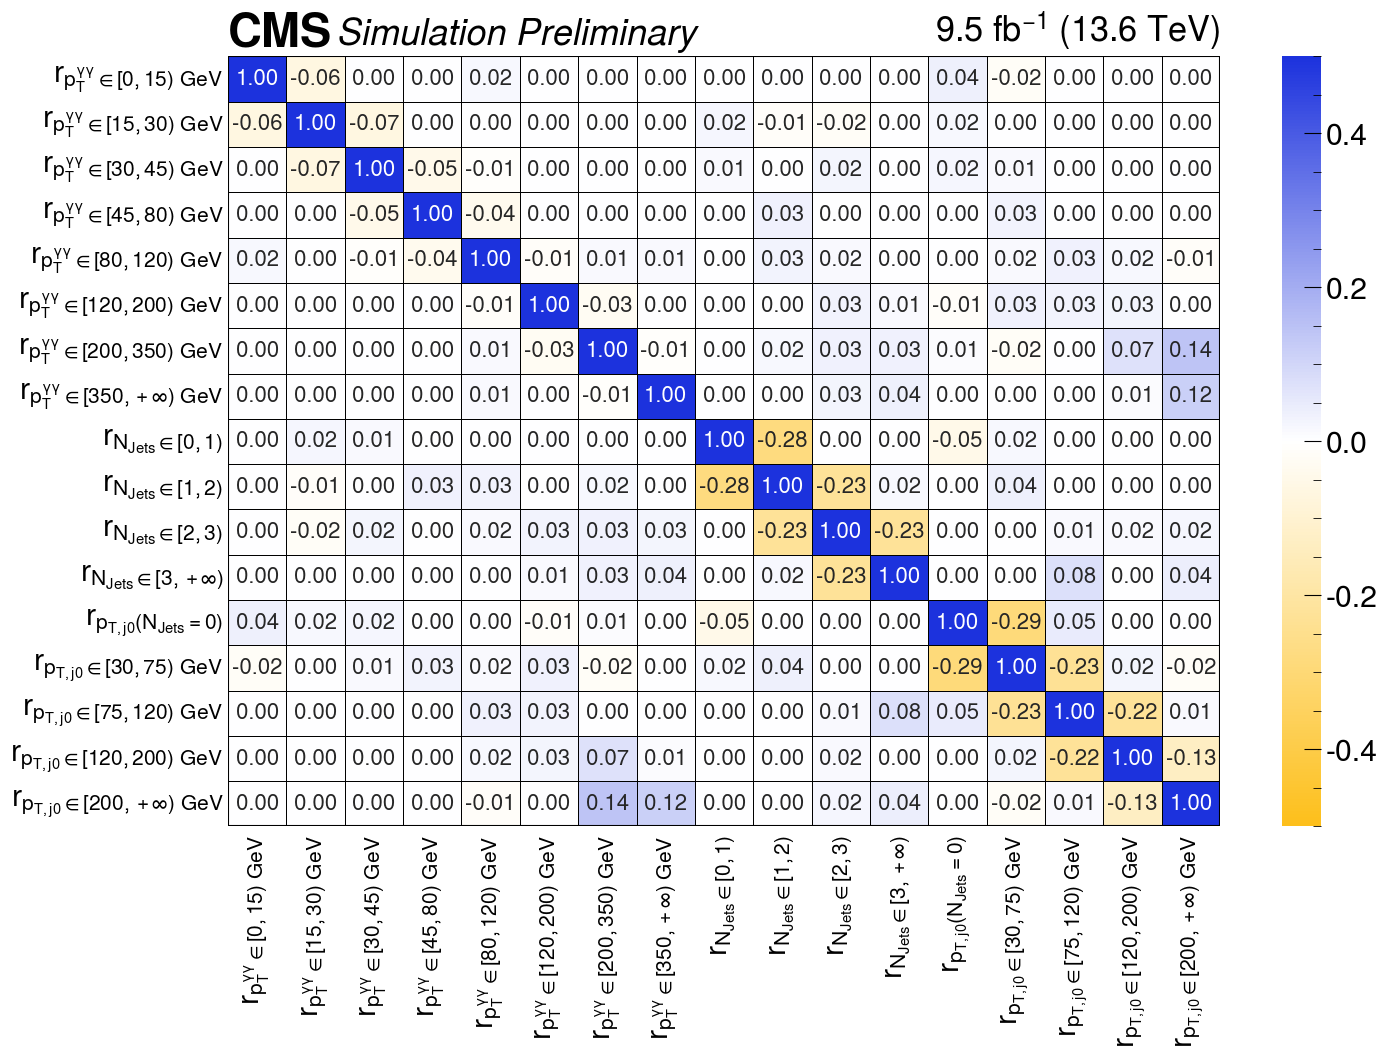

In [117]:
modified_corr_matrix = corr_matrix.copy()
modified_corr_matrix = modified_corr_matrix.where(abs(modified_corr_matrix) >= 0.01, 0)  # Set values greater than 0.1 to 0

modified_corr_matrix = modified_corr_matrix.rename(index=translation, columns=translation)

plt.figure(figsize=(16, 10))
plt.style.use(hep.style.CMS)
hep.cms.label('Preliminary', data=False, lumi=9.5, com=13.6)
ax = sns.heatmap(modified_corr_matrix, annot=True, cmap=custom_cmap, vmin=-0.5, vmax=0.5, annot_kws={"size": 16}, linewidths=0.5, linecolor='black', fmt=".2f")

ax.tick_params(
    axis='both',      # apply to both axes
    which='both',     # apply to both major and minor ticks
    bottom=False,     # remove bottom ticks
    top=False,        # remove top ticks
    left=False,       # remove left ticks
    right=False,      # remove right ticks
    labelbottom=True, # keep labels if you want
    labelleft=True    # keep labels if you want
)

# Get the number of rows and columns
n_rows, n_cols = modified_corr_matrix.shape

# Add rectangle around the whole heatmap to complete the outer box
rect = Rectangle(
    (0, 0),          # bottom left corner
    width=n_cols,    # number of columns
    height=n_rows,   # number of rows
    fill=False,      # no fill, just the edge
    edgecolor='black',
    linewidth=1.5
)
ax.add_patch(rect)

plt.savefig(os.path.join(plot_dir, "correlation_matrix.pdf"), bbox_inches='tight')
plt.savefig(os.path.join(plot_dir, "correlation_matrix.png"), bbox_inches='tight')

# plt.close()


In [118]:
z_hat = 0.5 * np.log((1 + corr_matrix) / (1 - corr_matrix)) + (corr_matrix / (2*(len(df_combined) - 2)))
a = np.tanh(z_hat - np.sqrt(1 / (len(df_combined) - 3)))
b = np.tanh(z_hat + np.sqrt(1 / (len(df_combined) - 3)))

In [119]:
b - corr_matrix

,r_PTH_0p0_15p0,r_PTH_15p0_30p0,r_PTH_30p0_45p0,r_PTH_45p0_80p0,r_PTH_80p0_120p0,r_PTH_120p0_200p0,r_PTH_200p0_350p0,r_PTH_350p0_10000p0,r_NJ_0p0_1p0,r_NJ_1p0_2p0,r_NJ_2p0_3p0,r_NJ_3p0_100p0,r_PTJ0_0p0_30p0,r_PTJ0_30p0_75p0,r_PTJ0_75p0_120p0,r_PTJ0_120p0_200p0,r_PTJ0_200p0_10000p0
r_PTH_0p0_15p0,0.000000,0.008360,0.008392,0.008392,0.008389,0.008392,0.008391,0.008391,0.008392,0.008391,0.008391,0.008392,0.008379,0.008390,0.008392,0.008392,0.008391
r_PTH_15p0_30p0,0.008360,0.000000,0.008357,0.008392,0.008391,0.008392,0.008391,0.008392,0.008387,0.008391,0.008390,0.008392,0.008389,0.008391,0.008392,0.008392,0.008392
r_PTH_30p0_45p0,0.008392,0.008357,0.000000,0.008376,0.008391,0.008391,0.008392,0.008391,0.008390,0.008392,0.008386,0.008391,0.008388,0.008390,0.008392,0.008392,0.008392
r_PTH_45p0_80p0,0.008392,0.008392,0.008376,0.000000,0.008382,0.008392,0.008392,0.008392,0.008391,0.008383,0.008392,0.008392,0.008391,0.008384,0.008392,0.008392,0.008392
r_PTH_80p0_120p0,0.008389,0.008391,0.008391,0.008382,0.000000,0.008391,0.008390,0.008390,0.008392,0.008384,0.008389,0.008392,0.008392,0.008389,0.008382,0.008389,0.008391
r_PTH_120p0_200p0,0.008392,0.008392,0.008391,0.008392,0.008391,0.000000,0.008387,0.008392,0.008392,0.008391,0.008383,0.008390,0.008391,0.008382,0.008383,0.008385,0.008392
r_PTH_200p0_350p0,0.008391,0.008391,0.008392,0.008392,0.008390,0.008387,0.000000,0.008391,0.008392,0.008389,0.008381,0.008382,0.008390,0.008390,0.008391,0.008346,0.008213
r_PTH_350p0_10000p0,0.008391,0.008392,0.008391,0.008392,0.008390,0.008392,0.008391,0.000000,0.008391,0.008392,0.008385,0.008379,0.008391,0.008392,0.008392,0.008391,0.008275
r_NJ_0p0_1p0,0.008392,0.008387,0.008390,0.008391,0.008392,0.008392,0.008392,0.008391,0.000000,0.007750,0.008392,0.008391,0.008374,0.008388,0.008392,0.008392,0.008391
r_NJ_1p0_2p0,0.008391,0.008391,0.008392,0.008383,0.008384,0.008391,0.008389,0.008392,0.007750,0.000000,0.007974,0.008389,0.008392,0.008379,0.008392,0.008391,0.008392


In [120]:
corr_matrix - a

,r_PTH_0p0_15p0,r_PTH_15p0_30p0,r_PTH_30p0_45p0,r_PTH_45p0_80p0,r_PTH_80p0_120p0,r_PTH_120p0_200p0,r_PTH_200p0_350p0,r_PTH_350p0_10000p0,r_NJ_0p0_1p0,r_NJ_1p0_2p0,r_NJ_2p0_3p0,r_NJ_3p0_100p0,r_PTJ0_0p0_30p0,r_PTJ0_30p0_75p0,r_PTJ0_75p0_120p0,r_PTJ0_120p0_200p0,r_PTJ0_200p0_10000p0
r_PTH_0p0_15p0,0.000000,0.008355,0.008392,0.008392,0.008390,0.008392,0.008392,0.008392,0.008391,0.008392,0.008392,0.008392,0.008382,0.008389,0.008392,0.008391,0.008392
r_PTH_15p0_30p0,0.008355,0.000000,0.008353,0.008391,0.008392,0.008392,0.008392,0.008392,0.008388,0.008390,0.008389,0.008392,0.008390,0.008392,0.008391,0.008392,0.008392
r_PTH_30p0_45p0,0.008392,0.008353,0.000000,0.008373,0.008391,0.008392,0.008391,0.008391,0.008391,0.008392,0.008388,0.008392,0.008389,0.008391,0.008391,0.008392,0.008392
r_PTH_45p0_80p0,0.008392,0.008391,0.008373,0.000000,0.008380,0.008392,0.008392,0.008392,0.008392,0.008385,0.008392,0.008392,0.008392,0.008386,0.008391,0.008392,0.008392
r_PTH_80p0_120p0,0.008390,0.008392,0.008391,0.008380,0.000000,0.008390,0.008391,0.008391,0.008391,0.008386,0.008390,0.008392,0.008392,0.008390,0.008385,0.008390,0.008390
r_PTH_120p0_200p0,0.008392,0.008392,0.008392,0.008392,0.008390,0.000000,0.008386,0.008392,0.008392,0.008392,0.008385,0.008391,0.008390,0.008384,0.008385,0.008387,0.008392
r_PTH_200p0_350p0,0.008392,0.008392,0.008391,0.008392,0.008391,0.008386,0.000000,0.008391,0.008391,0.008390,0.008383,0.008385,0.008391,0.008388,0.008392,0.008351,0.008223
r_PTH_350p0_10000p0,0.008392,0.008392,0.008391,0.008392,0.008391,0.008392,0.008391,0.000000,0.008392,0.008392,0.008387,0.008382,0.008392,0.008391,0.008392,0.008391,0.008283
r_NJ_0p0_1p0,0.008391,0.008388,0.008391,0.008392,0.008391,0.008392,0.008391,0.008392,0.000000,0.007732,0.008392,0.008392,0.008371,0.008390,0.008392,0.008392,0.008392
r_NJ_1p0_2p0,0.008392,0.008390,0.008392,0.008385,0.008386,0.008392,0.008390,0.008392,0.007732,0.000000,0.007959,0.008390,0.008392,0.008382,0.008392,0.008392,0.008392


In [121]:
# From Wikipedia https://en.wikipedia.org/wiki/Pearson_correlation_coefficient
np.sqrt((1 - corr_matrix**2) / (len(df_combined) - 2))

,r_PTH_0p0_15p0,r_PTH_15p0_30p0,r_PTH_30p0_45p0,r_PTH_45p0_80p0,r_PTH_80p0_120p0,r_PTH_120p0_200p0,r_PTH_200p0_350p0,r_PTH_350p0_10000p0,r_NJ_0p0_1p0,r_NJ_1p0_2p0,r_NJ_2p0_3p0,r_NJ_3p0_100p0,r_PTJ0_0p0_30p0,r_PTJ0_30p0_75p0,r_PTJ0_75p0_120p0,r_PTJ0_120p0_200p0,r_PTJ0_200p0_10000p0
r_PTH_0p0_15p0,0.000000,0.008375,0.008392,0.008392,0.008391,0.008392,0.008392,0.008391,0.008392,0.008392,0.008392,0.008392,0.008386,0.008391,0.008392,0.008392,0.008392
r_PTH_15p0_30p0,0.008375,0.000000,0.008373,0.008391,0.008392,0.008392,0.008392,0.008392,0.008390,0.008391,0.008390,0.008392,0.008391,0.008391,0.008392,0.008392,0.008392
r_PTH_30p0_45p0,0.008392,0.008373,0.000000,0.008383,0.008391,0.008392,0.008391,0.008391,0.008391,0.008392,0.008389,0.008392,0.008390,0.008391,0.008392,0.008392,0.008392
r_PTH_45p0_80p0,0.008392,0.008391,0.008383,0.000000,0.008386,0.008392,0.008392,0.008392,0.008392,0.008388,0.008392,0.008392,0.008391,0.008388,0.008392,0.008392,0.008392
r_PTH_80p0_120p0,0.008391,0.008392,0.008391,0.008386,0.000000,0.008391,0.008391,0.008391,0.008392,0.008388,0.008391,0.008392,0.008392,0.008391,0.008388,0.008391,0.008391
r_PTH_120p0_200p0,0.008392,0.008392,0.008392,0.008392,0.008391,0.000000,0.008389,0.008392,0.008392,0.008392,0.008388,0.008391,0.008391,0.008387,0.008388,0.008389,0.008392
r_PTH_200p0_350p0,0.008392,0.008392,0.008391,0.008392,0.008391,0.008389,0.000000,0.008391,0.008392,0.008391,0.008387,0.008388,0.008391,0.008390,0.008391,0.008370,0.008305
r_PTH_350p0_10000p0,0.008391,0.008392,0.008391,0.008392,0.008391,0.008392,0.008391,0.000000,0.008392,0.008392,0.008389,0.008386,0.008391,0.008392,0.008392,0.008391,0.008335
r_NJ_0p0_1p0,0.008392,0.008390,0.008391,0.008392,0.008392,0.008392,0.008392,0.008392,0.000000,0.008060,0.008392,0.008392,0.008382,0.008390,0.008392,0.008392,0.008391
r_NJ_1p0_2p0,0.008392,0.008391,0.008392,0.008388,0.008388,0.008392,0.008391,0.008392,0.008060,0.000000,0.008176,0.008391,0.008392,0.008386,0.008392,0.008392,0.008392


In [37]:
# Load combine toys
combineToy_dir = "/work/niharrin/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/CombineToy_Validation/toys"
variable = "PTH"

pois_untrimmed_combineToys = create_json_untrimmed(variable, combineToy_dir, poi_list, extra_name="_combineToys")
pois_combineToys = create_json_trimmed(variable, combineToy_dir, pois_untrimmed_combineToys, poi_list, subfolder_=f"SL_{variable}", extra_name="_combineToys")

Trimming values:  -4.638128443925213 6.941495012204484


In [38]:
df_combine = pd.DataFrame(pois_untrimmed_combineToys)
# --- Step 1: Identify rows WITHOUT -999 in either DataFrame ---
# Mask for df_PTH (True = valid, False = -999)
mask_combine = (df_combine != -999).all(axis=1)

# --- Step 2: Filter DataFrames ---
df_combine = df_combine[mask_combine]

# Calculate full correlation matrix
corr_matrix_combine = df_combine.corr()

<Axes: >

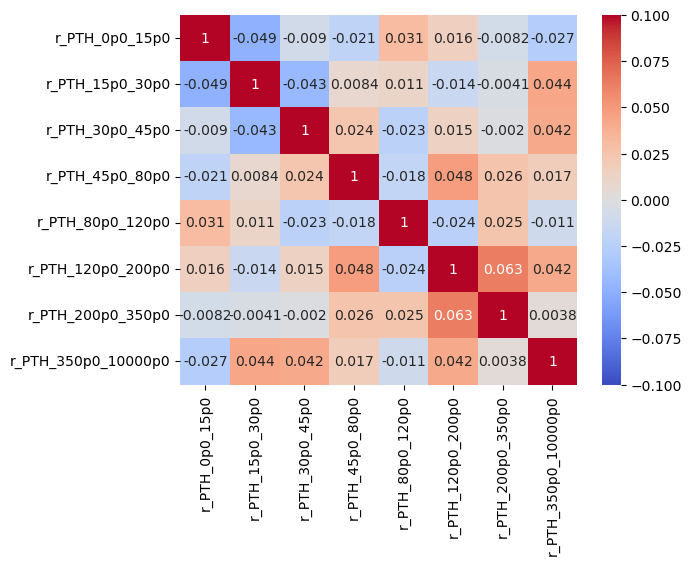

In [39]:
corr_matrix_combine
sns.heatmap(corr_matrix_combine, annot=True, cmap='coolwarm', vmin=-0.1, vmax=0.1)

<Axes: >

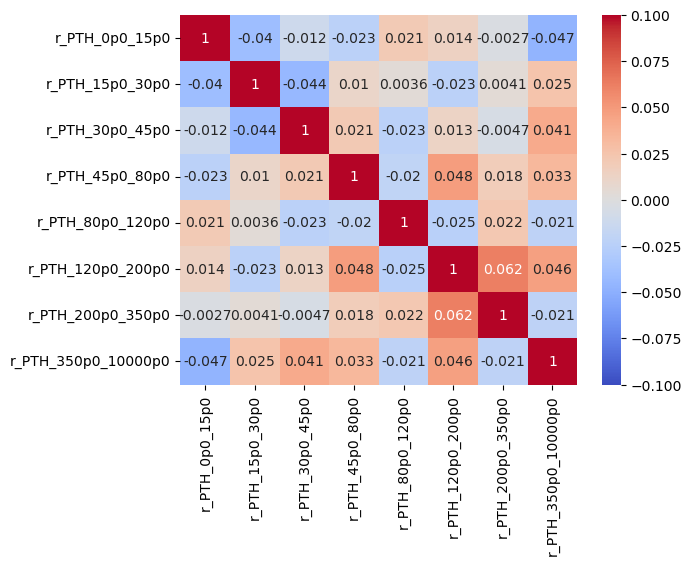

In [ ]:
# z = 5

<Axes: >

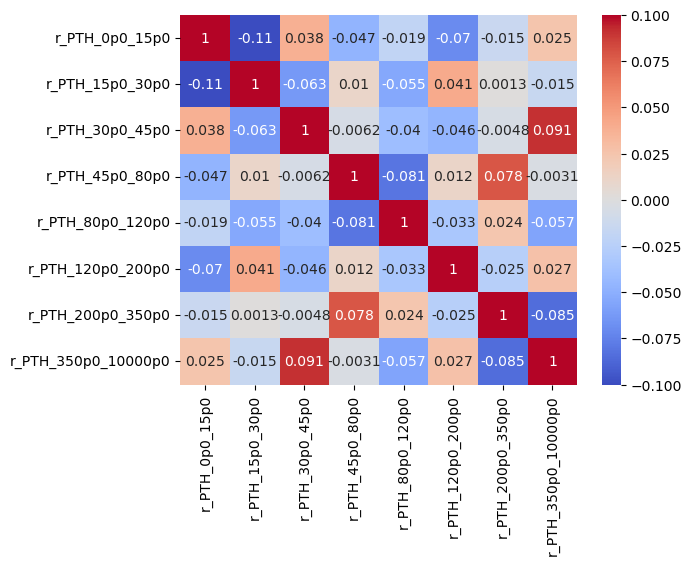

In [ ]:
# z = 1

<Axes: >

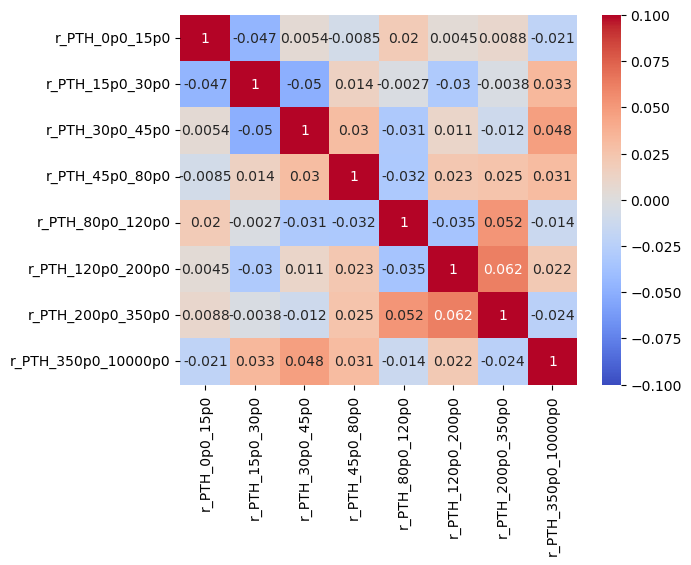

In [ ]:
# z = 2

<Axes: >

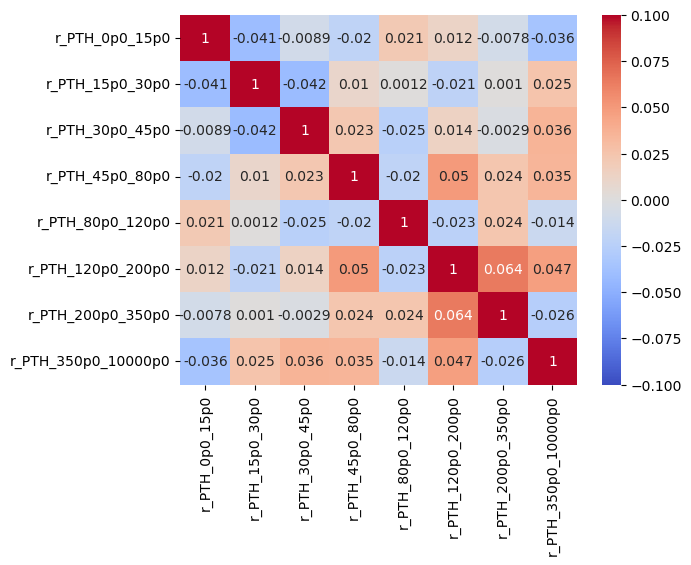

In [ ]:
# z = 4


In [40]:
np.corrcoef(df_combine["r_PTH_15p0_30p0"], df_combine["r_PTH_350p0_10000p0"])[0,1]

0.04367018650579769

In [41]:
df_combine = pd.DataFrame(pois_combineToys)
# --- Step 1: Identify rows WITHOUT -999 in either DataFrame ---
# Mask for df_PTH (True = valid, False = -999)
mask_combine = (df_combine != -999).all(axis=1)

# --- Step 2: Filter DataFrames ---
df_combine = df_combine[mask_combine]

# Calculate full correlation matrix
corr_matrix_combine = df_combine.corr()
np.corrcoef(df_combine["r_PTH_15p0_30p0"], df_combine["r_PTH_350p0_10000p0"])[0,1]

0.02500537248840066

In [42]:
plot_all_individual_correlation(pois_untrimmed_combineToys, poi_list, variable)

In [44]:
df_untrimmed_combine = pd.DataFrame(pois_untrimmed_combineToys)
# --- Step 1: Identify rows WITHOUT -999 in either DataFrame ---
# Mask for df_PTH (True = valid, False = -999)
mask_combine = (df_untrimmed_combine != -999).all(axis=1)

# --- Step 2: Filter DataFrames ---
df_untrimmed_combine = df_untrimmed_combine[mask_combine]

# Calculate full correlation matrix
corr_matrix_untrimmed_combine = df_untrimmed_combine.corr()

<Axes: >

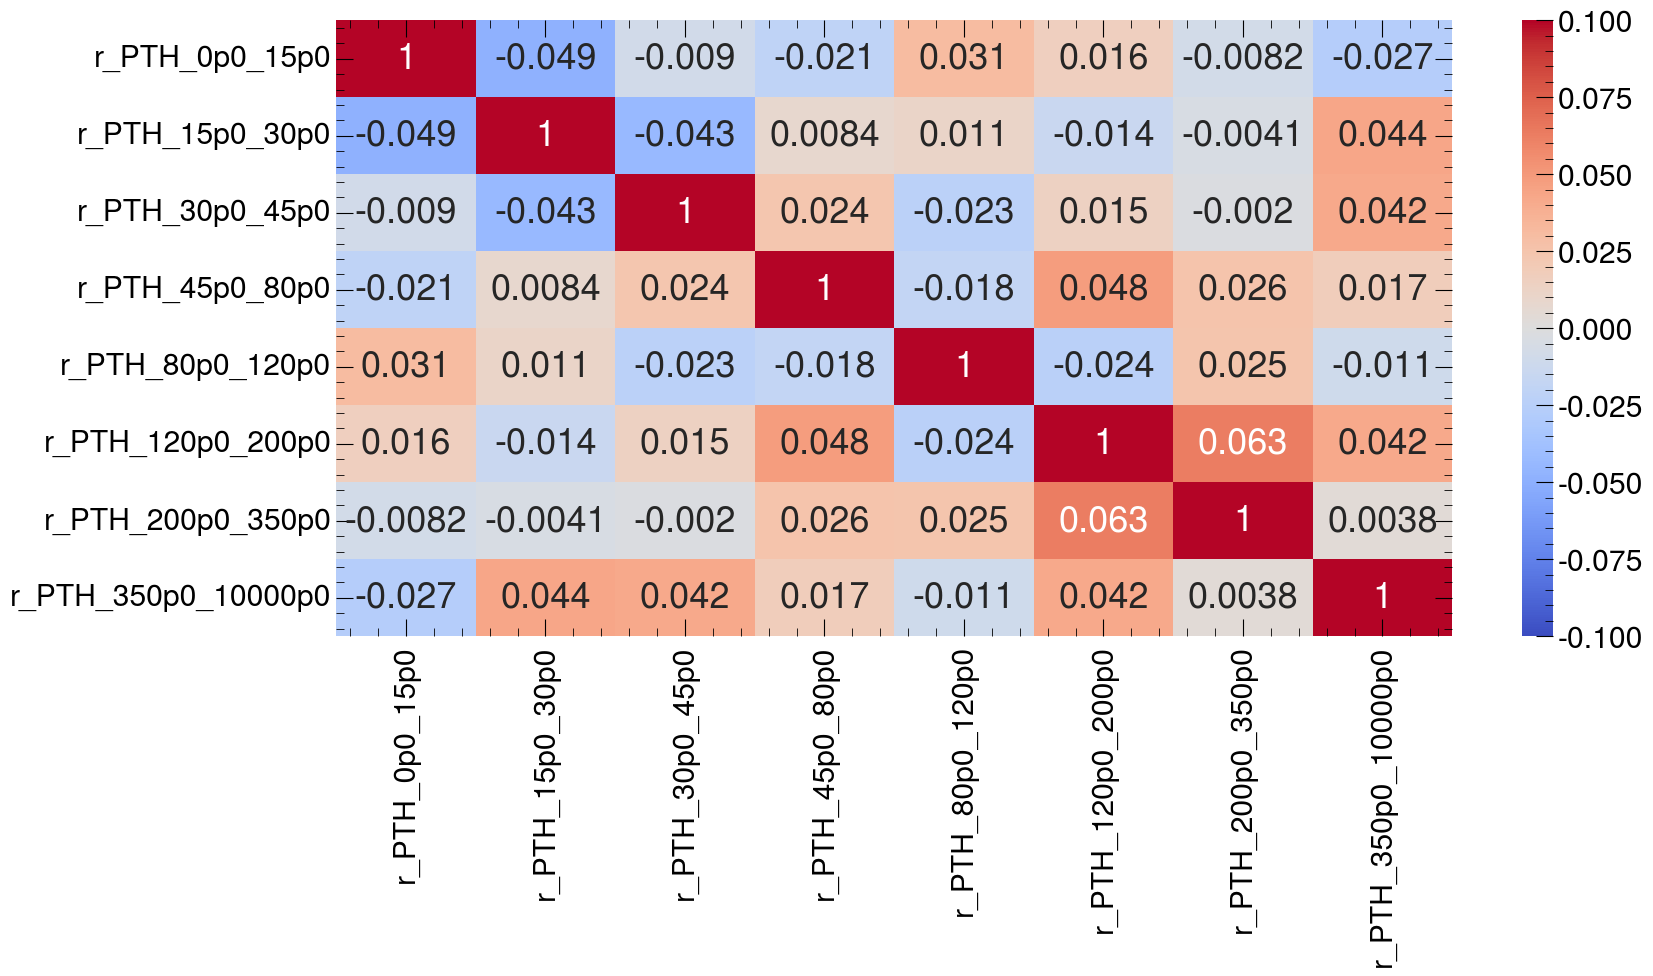

In [45]:
plt.figure(figsize=(18, 8))
sns.heatmap(corr_matrix_untrimmed_combine, annot=True, cmap='coolwarm', vmin=-0.1, vmax=0.1)